# Chapter 3 - Convolutional Neural Networks (CNNs)

### Loading "MNIST" to PyTorch

In [1]:
# Import dependencies
import torch
import torchvision
from torchvision import transforms
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import *
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
from idlmam import *

/home/efrain/Documents/Bio-AI-foundations/Inside_Deep_Learning/idlmam.py:7: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


In [5]:
# Downloading the MNIST data set
mnist_data_train = torchvision.datasets.MNIST("./data", train=True, download=True, transform=transforms.ToTensor())
mnist_data_test = torchvision.datasets.MNIST("./data", train=False, download=True, transform=transforms.ToTensor())


In [3]:
# Verify data as tensor
x_example, y_example = mnist_data_train[0]
print(type(x_example))
print(x_example.shape)

<class 'torch.Tensor'>
torch.Size([1, 28, 28])


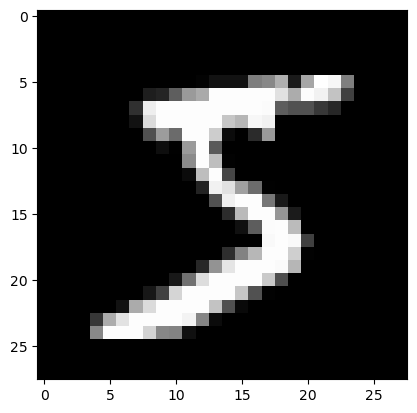

In [8]:
# Image visualization with "imsho"
plt.imshow(x_example[0,:], cmap='gray')

In [5]:
# Add 3 dimensions for Channels
x_as_color = torch.stack([x_example[0,:], x_example[0,:], x_example[0,:]], dim=0)
print(x_as_color.shape)

torch.Size([3, 28, 28])


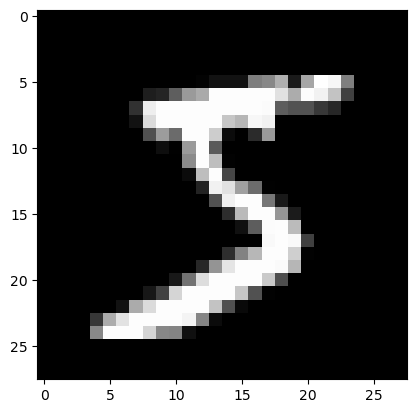

In [6]:
# permute images in imshow
plt.imshow(x_as_color.permute(1,2,0))

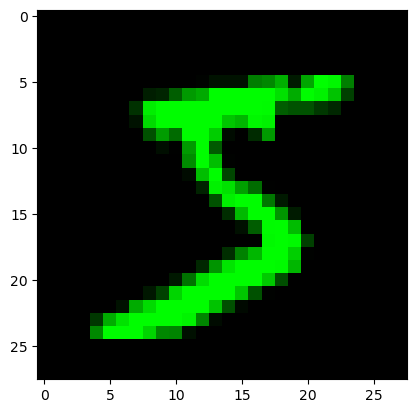

In [10]:
# Zero out the red and blue channels to get a green image
x_as_color = torch.stack([x_example[0,:], x_example[0,:], x_example[0,:]])
x_as_color[0,:] = 0
x_as_color[2,:] = 0
plt.imshow(x_as_color.permute(1,2,0))

Mix several images of different colors to see the difference in representation using torch.stack

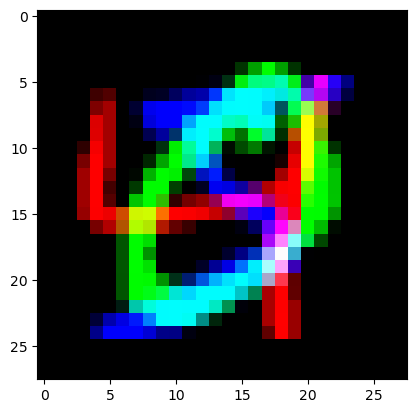

In [ ]:
# Using a 5 (blue), 4 (red) and 0 (green)
x1, x2, x3 = mnist_data_train[0], mnist_data_train[1], mnist_data_train[2]
x1, x2, x3 = x1[0], x2[0], x3[0]
x_as_color = torch.stack([x3[0,:], x2[0,:], x1[0,:]], dim=0)
plt.imshow(x_as_color.permute(1,2,0))

Shuffling the data from the number "5" to see the impact

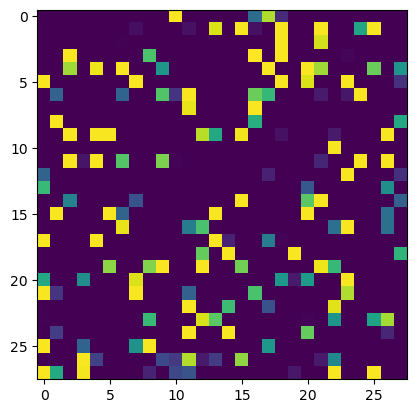

In [22]:
random_order = torch.randperm(x_example.shape[1] * x_example.shape[2])
x_shuffled = x_example.view(-1)[random_order].view(x_example.shape)
plt.imshow(x_shuffled[0,:])

## Definition of Convolutions
Convolution is a mathematical function with two inputs: an "image" an a "filter" (kernel) and ouput a new image. The purpose of a convolution filter is to recognize patterns in an given image.

The Spatial relationship: "Things near each other are related, and things far from each other have no relationship"

### 1D Convolutions (C,W) shape
Examples

In [30]:
# 1D input with filter size K=1 (1 dimension)
filter =[1, 0, -1]
input = [1, 0, 2, -1, 1, 2]
output = []

for i in range(len(input)-len(filter)+1):
    result = 0
    for j in range (len(filter)):
        result += input[i+j]*filter[j]
    output.append(result)

print(output)

[-1, 1, 1, -3]


### 2D Convolutions (C,W) K=3

In [ ]:
# 2D input with a filter size K=3 (3 dimensions)
filter = [[0,1,0],
          [0,1,0],
          [0,1,0]]

input = [[0,0,1,1,0,0],
         [0,1,0,1,0,0],
         [0,0,0,1,0,0],
         [0,0,0,1,0,0],
         [0,0,0,1,1,0],
         [0,1,1,1,1,1]]

height, width = len(input), len(input[0])
output = []

for i in range(height-len(filter) + 1): # slides filter over rows
    row_out = []
    for j in range(width-len(filter) + 1): # slides filter over columns
        result = 0
        for k_i in range(len(filter)): # applies filter at this location
            for k_j in range(len(filter)):
                result += input[i+k_i][j+k_j]*filter[k_i][k_j]
            
        row_out.append(result)
    output.append(row_out)

output

[[1, 1, 3, 0], [1, 0, 3, 0], [0, 0, 3, 1], [1, 1, 3, 2]]

### Convolutions in image processing

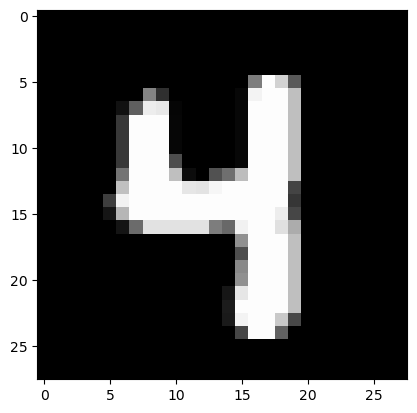

In [5]:
from scipy.signal import convolve
img_indx = 58
img = mnist_data_train[img_indx][0][0,:]
plt.imshow(img, vmin=0, vmax=1, cmap='gray')

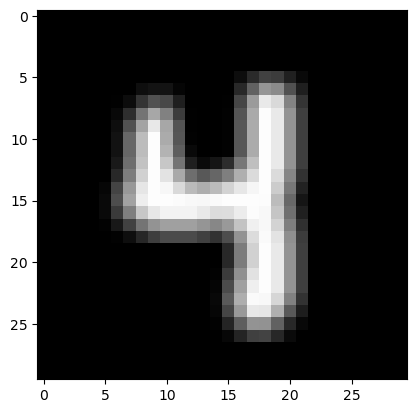

In [7]:
# Getting a blurry image with a filter
blur_filter = np.asarray([[1,1,1],
                          [1,1,1],
                          [1,1,1]])/9.0

blurry_image = convolve(img, blur_filter)
plt.imshow(blurry_image, vmin=0, vmax=1, cmap='gray')


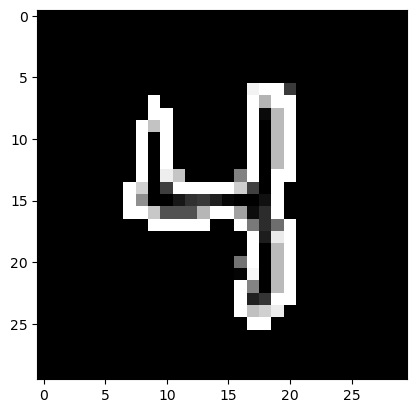

In [8]:
# Applyin an edge kernel.
edge_filter = np.asarray([[-1,-1,-1],
                          [-1, 8,-1],
                          [-1,-1,-1]])

edge_image = convolve(img, edge_filter)
plt.imshow(edge_image, vmin=0, vmax=1, cmap='gray')

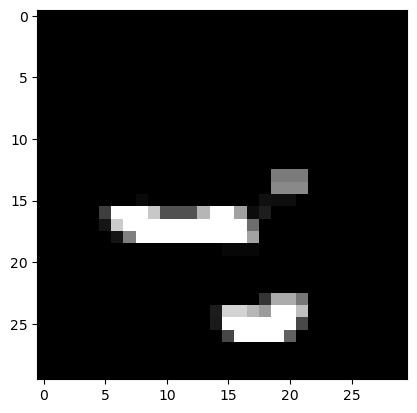

In [11]:
# applying a 3x3 kernel to find horizontal edges
h_edge_filter = np.asarray([[-1,-1,-1],
                            [ 0, 0, 0],
                            [ 1, 1, 1]])

h_edge_image =  convolve(img, h_edge_filter)
plt.imshow(h_edge_image, vmin=0, vmax=1, cmap='gray')

### Creating my first Convolutional Neural Network (CNN)

In [2]:
# Verification of CUDA present
if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

In [3]:
device

device(type='cuda')

In [6]:
# Create a DataLoader
B = 32 #Batch size
mnist_train_loader = DataLoader(mnist_data_train, batch_size=B, shuffle=True)
mnist_test_loader = DataLoader(mnist_data_test, batch_size=B)

In [7]:
# CREATING THE CNN MODEL

# Determine de layers of subsequent layers
D = 28*28
# Channels in the input (1 for grayscale)
C = 1
# Number of classes
classes = 10
# Number of filters used
filters = 16
# filters size
K = 3

# Define a linear model for comparison
model_linear = nn.Sequential(
    nn.Flatten(), # (B, C, W, H) -> (B, C*W*H) = (B, D)
    nn.Linear(D, 256),
    nn.Tanh(),
    nn.Linear(256, classes)
)

# Now the simple CNN. Conv2d
model_cnn = nn.Sequential(
    nn.Conv2d(C, filters, K, padding=K//2), # x(conv)D
    nn.Tanh(),
    nn.Flatten(),
    nn.Linear(filters*D, classes)
)

In [8]:
# TRAINING THE MODELS

from sklearn.metrics import accuracy_score
# Define Loss Function
loss_func = nn.CrossEntropyLoss()

# FULLY CONNECTED MODEL
fc_results = train_simple_network(model_linear, loss_func,
                                  mnist_train_loader, test_loader=mnist_test_loader,
                                  score_funcs={'Accuracy': accuracy_score},
                                  device=device,
                                  epochs=20)

Epoch: 100%|██████████| 20/20 [03:10<00:00,  9.54s/it]


In [9]:
# CNN MODEL
cnn_results = train_simple_network(model_cnn, loss_func,
                                   mnist_train_loader,
                                   test_loader=mnist_test_loader,
                                   score_funcs={'Accuracy': accuracy_score},
                                   device=device,
                                   epochs=20)


Epoch: 100%|██████████| 20/20 [03:13<00:00,  9.67s/it]


<Axes: xlabel='epoch', ylabel='test Accuracy'>

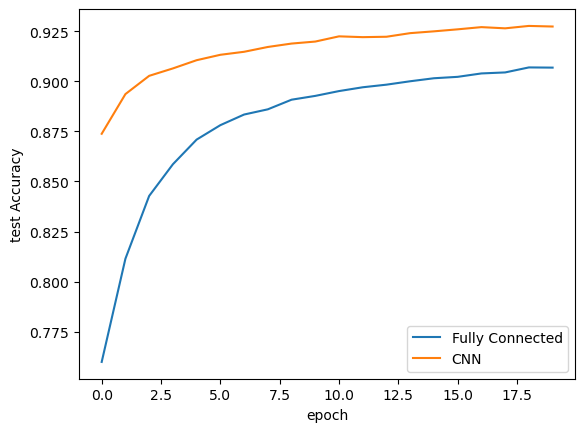

In [10]:
# COMPARE MODELS

sns.lineplot(x='epoch', y='test Accuracy', data=fc_results, label='Fully Connected')
sns.lineplot(x='epoch', y='test Accuracy', data=cnn_results, label='CNN')